In [31]:
import numpy as np
from matplotlib import pyplot as plt

In [32]:
num_exp = 8
num_act = 2
lr = 0.02
seed = 1
#/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250910_064242/width512_depth14_experts8_active2_seed0_lr0.02/router_weights_iter_1.npy
#/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250909_164542/width512_depth14_experts4_active1_seed0_lr0.02/router_weights_iter_1.npy
for iter_idx in range(5):
    ind = 1000 * iter_idx + 1
    file_path = f"/home/ubuntu/MuP_MOE/run_data/mutransfer_lr_cccc/out_20250910_064242/width512_depth14_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}/router_weights_iter_{ind}.npy"
    router_weights = np.load(file_path)
    print(router_weights.shape)
    print(np.linalg.norm(router_weights[0][1, 1]))
    print(np.linalg.norm(router_weights[6][1, 1]))
    print(np.linalg.norm(router_weights[-1][1, 1]))
    print()

(14, 8, 512)
0.008178567
0.0013638487
0.016241597

(14, 8, 512)
0.010773151
0.0011901691
0.016023157

(14, 8, 512)
0.0095231
0.007822908
0.01610833

(14, 8, 512)
0.0072710468
0.030455671
0.0150794275

(14, 8, 512)
0.005282097
0.0080600865
0.012192729



In [56]:
def load_router_weights(file_path='/home/ubuntu/MuP_MOE/gpt_oss_router/router_weights.pt'):
    router_weights = torch.load(file_path, map_location='cpu')
    num_layers = len(router_weights)
    matrices = []
    for i in range(num_layers):
        layer_key = f'layer_{i}'
        matrix = router_weights[layer_key].numpy()
        matrices.append(matrix)
    return matrices


In [64]:
matrices_120 = load_router_weights(file_path='/home/ubuntu/MuP_MOE/gpt_oss_router_120/router_weights.pt')
matrices_20 = load_router_weights(file_path='/home/ubuntu/MuP_MOE/gpt_oss_router/router_weights.pt')

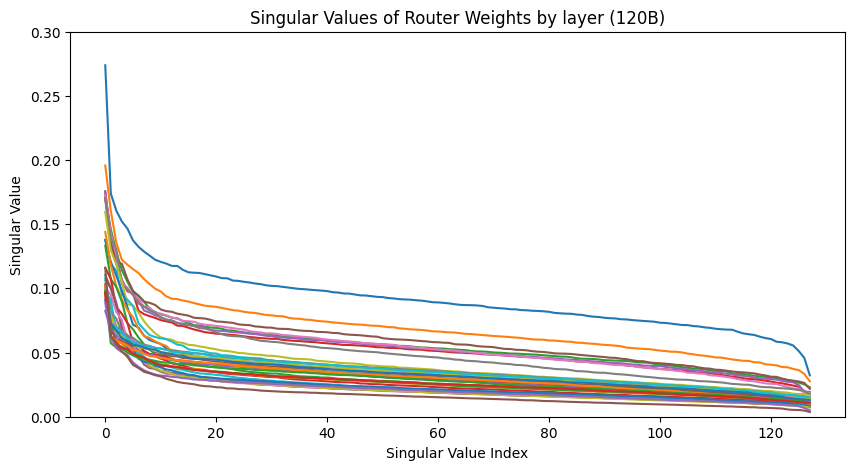

In [65]:
plt.figure(figsize=(10, 5))
for i in range(len(matrices_120)):
    matrix = np.array(matrices_120[i], dtype=np.float32)
    plt.plot(np.linalg.svd(matrix)[1]/np.sqrt(128), label=f"Layer {i}")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.ylim(0, 0.3)
plt.title("Singular Values of Router Weights by layer (120B)")
plt.show()

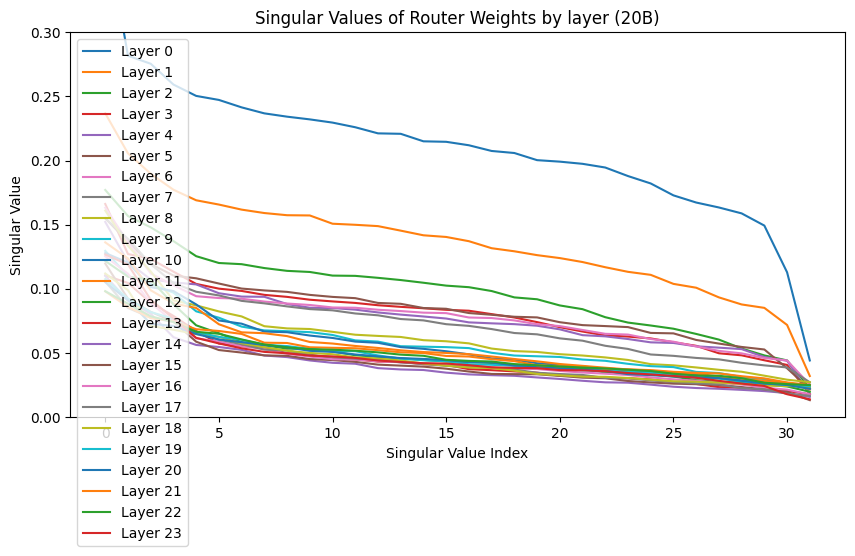

In [67]:
plt.figure(figsize=(10, 5))
for i in range(len(matrices_20)):
    matrix = np.array(matrices_20[i], dtype=np.float32)
    plt.plot(np.linalg.svd(matrix)[1]/np.sqrt(32), label=f"Layer {i}")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.ylim(0, 0.3)
plt.title("Singular Values of Router Weights by layer (20B)")
plt.legend()
plt.show()

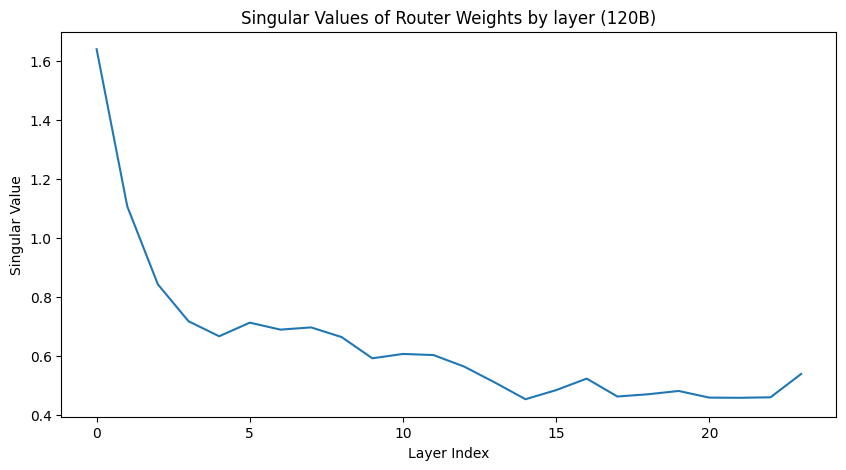

In [68]:
plt.figure(figsize=(10, 5))
list_svd = []
for i in range(len(matrices_20)):
    matrix = np.array(matrices_20[i], dtype=np.float32)
    list_svd.append(np.mean(np.linalg.svd(matrix)[1][:5]))
plt.plot(list_svd, label=f"Layer {i}")
plt.xlabel("Layer Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of Router Weights by layer (120B)")
plt.show()

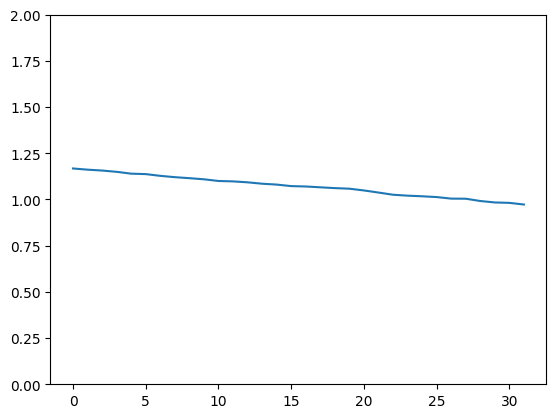

In [35]:
shape = (32, 2880)
#generate a random matrix with the same shape
matrix = np.random.randn(*shape) * 0.02
plt.plot(np.linalg.svd(matrix)[1], label=f"Random Matrix")
plt.ylim(0, 2)
plt.show()
